In [4]:
import torch
from torch import nn
import torch.utils.data as data
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from torch import optim
import torchvision
from torch import nn
from torch.utils.data import DataLoader, random_split, Subset
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns
%matplotlib inline


In [6]:
train_data_path = "C:/Users/HAROON TRADERS\Documents/DS Stuff/cifake-pytorch/data-folder/train"
test_data_path = "C:/Users/HAROON TRADERS\Documents/DS Stuff/cifake-pytorch/data-folder/test"
BATCH_SIZE = 64
IMG_SIZE = 224
transformIMG = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale = (0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.RandomAdjustSharpness(2, p=0.3),

    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225] )
    ]
)


train_data_main = torchvision.datasets.ImageFolder(root = train_data_path, transform = transformIMG)

total_size = len(train_data_main)
val_size = int(0.15 * total_size)
train_size = total_size - val_size

train_data, val_data = random_split(train_data_main, [train_size, val_size])

train_data_loader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)
val_data_loader = data.DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)

test_data = torchvision.datasets.ImageFolder(root = test_data_path, transform = transformIMG)
test_data_loader = data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

Training samples: 85000
Validation samples: 15000
Test samples: 20000


In [7]:
CNN1 = nn.Conv2d(
    in_channels=3,
    out_channels=32,
    kernel_size=3,
    stride=1,
    padding=1)

CNN2 = nn.Conv2d(
    in_channels=32,
    out_channels=64,
    kernel_size=3,
    stride=1,
    padding=1
    )

In [8]:
for i, (X_train, y_train) in enumerate(train_data_loader):
    print(f"Batch {i+1}")
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    break

Batch 1
X_train shape: torch.Size([64, 3, 224, 224])
y_train shape: torch.Size([64])


In [9]:
x = X_train

x = CNN1(x)
print(x.shape)

x = F.max_pool2d(x ,2,2)
print(x.shape)


x = CNN2(x)
print(x.shape)

x = F.max_pool2d(x ,2,2)
print(x.shape)

torch.Size([64, 32, 224, 224])
torch.Size([64, 32, 112, 112])
torch.Size([64, 64, 112, 112])
torch.Size([64, 64, 56, 56])


In [10]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
    self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
    self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

    self.pool = nn.MaxPool2d(2, 2)
    self.gap = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(64, 2)
    self.dropout = nn.Dropout(0.5)

  def forward(self, X):

      X = self.pool(F.relu(self.conv1(X)))  # 256 → 128
      X = self.pool(F.relu(self.conv2(X)))  # 128 → 64
      X = self.pool(F.relu(self.conv3(X)))  # 64 → 32

      X = self.gap(X)                      # → (B, 64, 1, 1)
      X = torch.flatten(X, 1)              # → (B, 64)

      X = self.fc(X)

      return X


In [11]:
model = CNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [ ]:
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
num_epochs = 3
total_images = len(train_data_loader.dataset)

losses = []
val_losses = []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()

    processed_images = 0
    pbar = tqdm(train_data_loader, desc=f"Epoch {epoch+1}/{num_epochs}", ncols=100)

    # 🔹 TRAINING LOOP
    for batch_idx, (images, labels) in enumerate(pbar):
        batch_size = images.size(0)
        processed_images += batch_size

        images, labels = images.to(device), labels.to(device)

        scores = model(images)
        loss = criterion(scores, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        pbar.set_postfix({
            "Train Loss": f"{loss.item():.4f}",
            "Processed": f"{processed_images}/{total_images}"
        })

    # 🔹 VALIDATION LOOP (AFTER EPOCH)
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)
            val_loss += loss.item()

    val_loss /= len(val_data_loader)
    val_losses.append(val_loss)

    print(f"\nEpoch {epoch+1} Validation Loss: {val_loss:.4f}")

    best_val_loss = 0.5

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth-2")
        print("✅ Saved new best model")

# 🔹 TIME TRACKING
end_time = time.time()
total_time = end_time - start_time

print("\nTraining Finished")
print(f"Total Time: {total_time:.2f} seconds")
print(f"Total Time: {total_time/60:.2f} minutes")

# 🔹 PLOT LOSSES & PRED
plt.plot(preds, label="Prediction")
plt.plot(losses, label="Train Loss")
plt.plot(
    [i * len(train_data_loader) for i in range(len(val_losses))],
    val_losses,
    label="Validation Loss",
    marker='o'
)

plt.xlabel("Batch number")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Epoch 1/3:   5%|▍        | 64/1329 [01:30<24:43,  1.17s/it, Train Loss=0.6889, Processed=4096/85000]

Test Accuracy: 86.0100 %

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86     10000
           1       0.88      0.83      0.86     10000

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



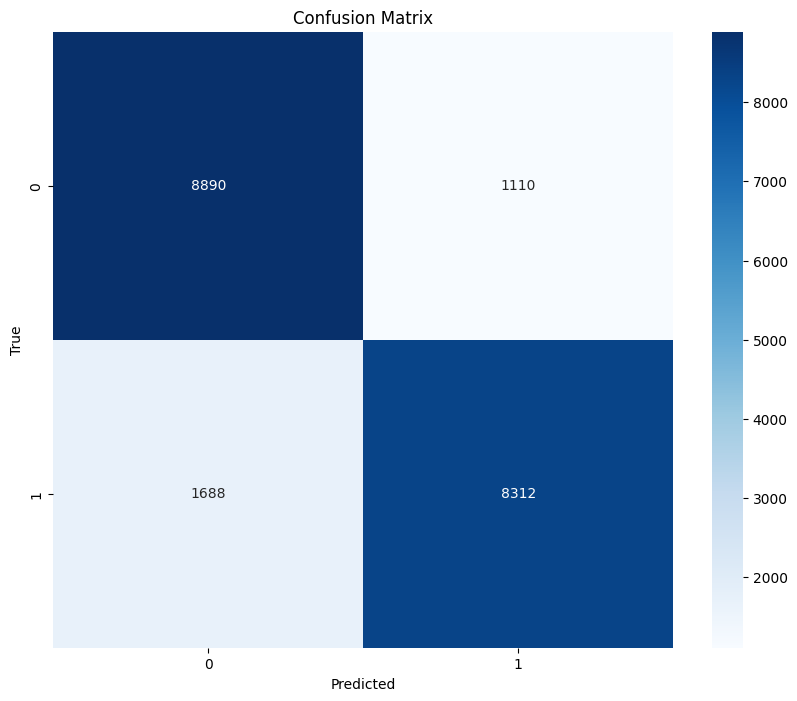

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
all_preds = []
all_labels = []


model.eval()

with torch.no_grad():
        for images, labels in test_data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)

print(f"Test Accuracy: {acc * 100:.4f} %")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()